<a href="https://colab.research.google.com/github/nananana25/MSI140/blob/main/MIS140A2_Praba_200000072.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import itertools

In [ ]:
url = '/content/GlideWise360_A2.csv'
df = pd.read_csv(url)

In [ ]:
df

,timestamp,hour,day,month,year,is_holiday,is_weekend,season,t1,t2,hum,wind_speed,weather_code,cnt
0,2015-01-04 00:00:00,0,4,1,2015,0.0,1.0,Winter,3.0,2.0,93.0,6.0,3.0,182.0
1,2015-01-04 01:00:00,1,4,1,2015,0.0,1.0,Winter,3.0,2.5,93.0,5.0,1.0,138.0
2,2015-01-04 02:00:00,2,4,1,2015,0.0,1.0,Winter,2.5,2.5,96.5,0.0,1.0,134.0
3,2015-01-04 03:00:00,3,4,1,2015,0.0,1.0,Winter,2.0,2.0,100.0,0.0,1.0,72.0
4,2015-01-04 04:00:00,4,4,1,2015,0.0,1.0,Winter,2.0,0.0,93.0,6.5,1.0,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14448,2016-08-31 19:00:00,19,31,8,2016,0.0,0.0,Summer,22.0,22.0,65.0,21.5,2.0,2750.0
14449,2016-08-31 20:00:00,20,31,8,2016,0.0,0.0,Summer,21.0,21.0,69.0,23.0,2.0,1515.0
14450,2016-08-31 21:00:00,21,31,8,2016,0.0,0.0,Summer,20.0,20.0,71.0,19.0,2.0,1134.0
14451,2016-08-31 22:00:00,22,31,8,2016,0.0,0.0,Summer,19.0,19.0,64.0,19.5,1.0,853.0


In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14453 entries, 0 to 14452
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     14453 non-null  object 
 1   hour          14453 non-null  int64  
 2   day           14453 non-null  int64  
 3   month         14453 non-null  int64  
 4   year          14453 non-null  int64  
 5   is_holiday    14453 non-null  float64
 6   is_weekend    14453 non-null  float64
 7   season        14311 non-null  object 
 8   t1            14308 non-null  float64
 9   t2            14308 non-null  float64
 10  hum           14308 non-null  float64
 11  wind_speed    14308 non-null  float64
 12  weather_code  14453 non-null  float64
 13  cnt           14309 non-null  object 
dtypes: float64(7), int64(4), object(3)
memory usage: 1.5+ MB


In [ ]:
df.isna().sum()

,0
timestamp,0
hour,0
day,0
month,0
year,0
is_holiday,0
is_weekend,0
season,142
t1,145
t2,145


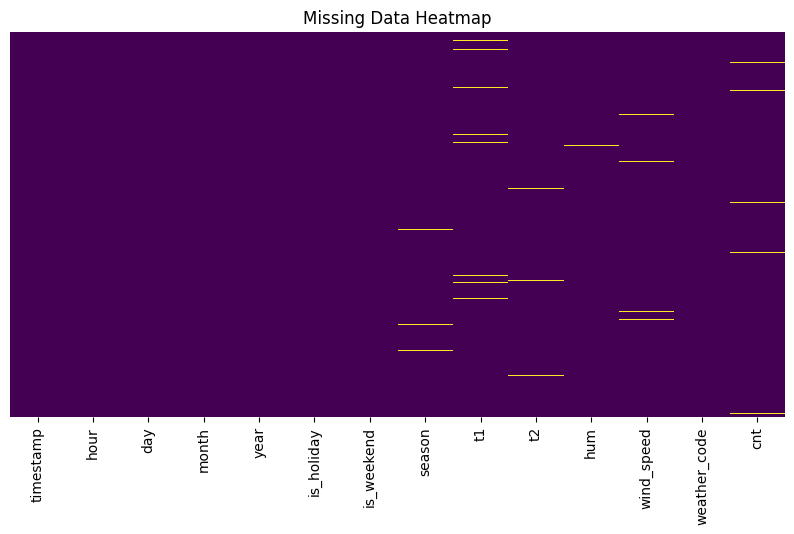

In [ ]:
# Plot missing values as a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False, yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head()

,timestamp,hour,day,month,year,is_holiday,is_weekend,season,t1,t2,hum,wind_speed,weather_code,cnt
0,2015-01-04 00:00:00,0,4,1,2015,0.0,1.0,Winter,3.0,2.0,93.0,6.0,3.0,182.0
1,2015-01-04 01:00:00,1,4,1,2015,0.0,1.0,Winter,3.0,2.5,93.0,5.0,1.0,138.0
2,2015-01-04 02:00:00,2,4,1,2015,0.0,1.0,Winter,2.5,2.5,96.5,0.0,1.0,134.0
3,2015-01-04 03:00:00,3,4,1,2015,0.0,1.0,Winter,2.0,2.0,100.0,0.0,1.0,72.0
4,2015-01-04 04:00:00,4,4,1,2015,0.0,1.0,Winter,2.0,0.0,93.0,6.5,1.0,47.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13610 entries, 0 to 14452
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     13610 non-null  object 
 1   hour          13610 non-null  int64  
 2   day           13610 non-null  int64  
 3   month         13610 non-null  int64  
 4   year          13610 non-null  int64  
 5   is_holiday    13610 non-null  float64
 6   is_weekend    13610 non-null  float64
 7   season        13610 non-null  object 
 8   t1            13610 non-null  float64
 9   t2            13610 non-null  float64
 10  hum           13610 non-null  float64
 11  wind_speed    13610 non-null  float64
 12  weather_code  13610 non-null  float64
 13  cnt           13610 non-null  object 
dtypes: float64(7), int64(4), object(3)
memory usage: 2.1+ MB


In [ ]:
df.isna().sum()

,0
timestamp,0
hour,0
day,0
month,0
year,0
is_holiday,0
is_weekend,0
season,0
t1,0
t2,0


### 1. UNIVARIATE ANALYSIS

NUMERICAL VARIABLES

In [ ]:
df.describe()

,hour,day,month,year,is_holiday,is_weekend,t1,t2,hum,wind_speed,weather_code,cnt
count,13545.000000,13545.000000,13545.000000,13545.000000,13545.000000,13545.000000,13545.000000,13545.000000,13545.000000,13545.000000,13545.000000,13545.000000
mean,11.511185,15.782429,5.733260,2015.403322,0.021779,0.282318,12.826504,11.915836,71.375581,18.524948,2.731414,1322.538427
std,6.917829,8.776099,3.180707,0.490582,0.145967,0.450144,10.551797,11.305436,19.007652,24.734434,2.371302,2163.375244
min,0.000000,1.000000,1.000000,2015.000000,0.000000,0.000000,-40.000000,-40.000000,-8.000000,-9.000000,1.000000,-13.000000
25%,6.000000,8.000000,3.000000,2015.000000,0.000000,0.000000,8.500000,6.000000,61.000000,10.000000,1.000000,242.000000
50%,12.000000,16.000000,6.000000,2015.000000,0.000000,0.000000,13.000000,13.000000,73.500000,16.000000,2.000000,844.000000
75%,17.000000,23.000000,8.000000,2016.000000,0.000000,1.000000,17.000000,17.000000,82.000000,21.000000,3.000000,1717.000000
max,23.000000,31.000000,12.000000,2016.000000,1.000000,1.000000,85.000000,88.000000,170.000000,250.000000,26.000000,20000.000000


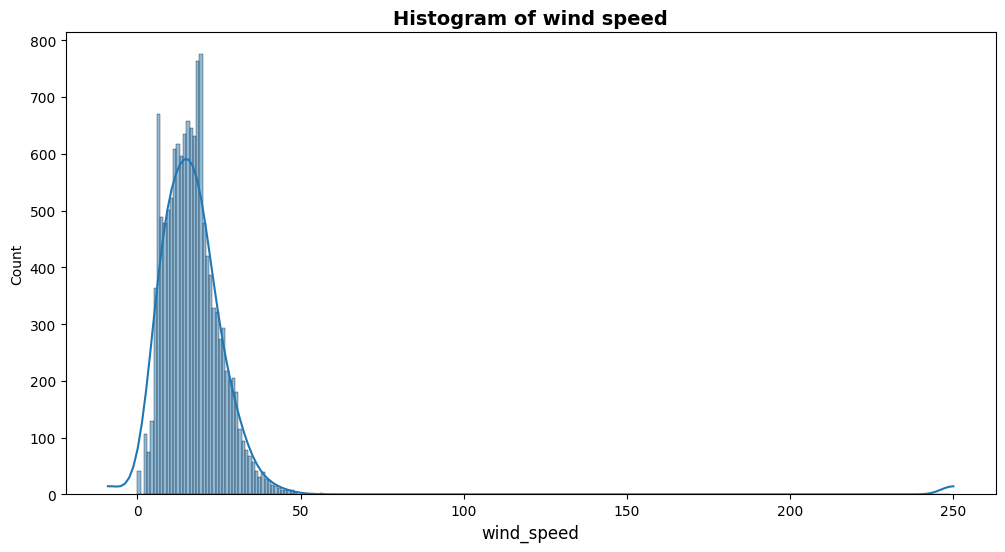

In [ ]:
# Create a professional histogram of wind speed with clearly labeled x-axis
plt.figure(figsize=(12, 6))

# Define bin edges
bin_edges = range(0, int(df['wind_speed'].max()) )

# Plot the histogram with defined bins
sns.histplot(data=df, x="wind_speed", bins=bin_edges, kde=True)

# Set title and labels
plt.title("Histogram of wind speed", fontsize=14, fontweight='bold')
plt.xlabel("wind_speed", fontsize=12)


# Show the plot
plt.show()

In [ ]:
df['cnt'] = pd.to_numeric(df['cnt'], errors='coerce')

In [ ]:
# Check if any NaN values were introduced after conversion
if df['cnt'].isnull().any():
    print(f"Warning: {df['cnt'].isnull().sum()} NaN values found in 'cnt' after conversion. Dropping them for plotting.")
    df.dropna(subset=['cnt'], inplace=True)


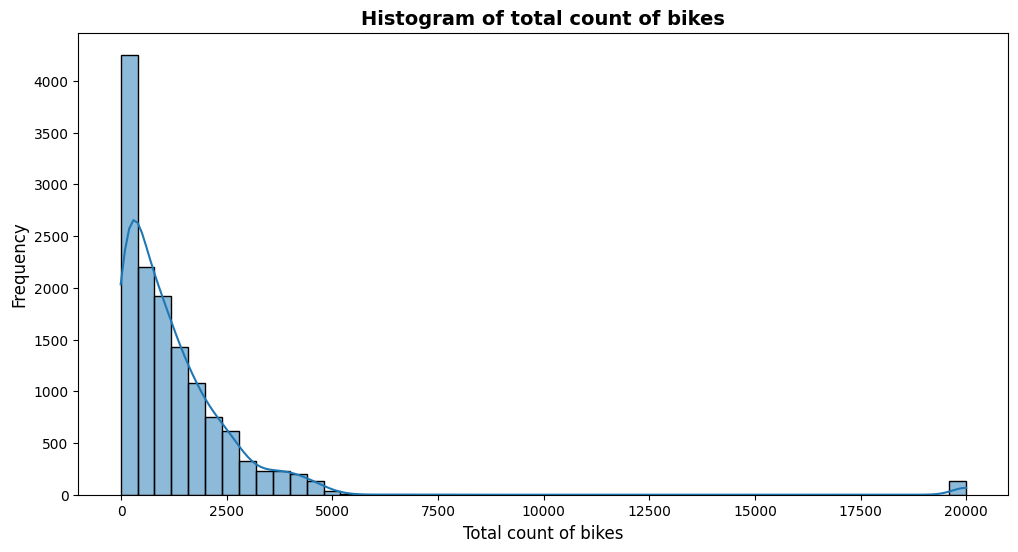

In [ ]:
# Create a professional histogram of 'cnt' with clearly labeled x-axis
plt.figure(figsize=(12, 6))

# Define bin edges. Use a reasonable number of bins for count data.
# Given 'cnt' is likely counts, let's use a dynamic bin calculation or a fixed number.
# Let's try 50 bins or max/min range.
bin_edges = np.arange(df['cnt'].min(), df['cnt'].max() + 1, (df['cnt'].max() - df['cnt'].min()) / 50)

# Plot the histogram with defined bins
sns.histplot(data=df, x='cnt', bins=bin_edges, kde=True)

# Set title and labels
plt.title("Histogram of total count of bikes", fontsize=14, fontweight='bold')
plt.xlabel("Total count of bikes", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Show the plot
plt.show()

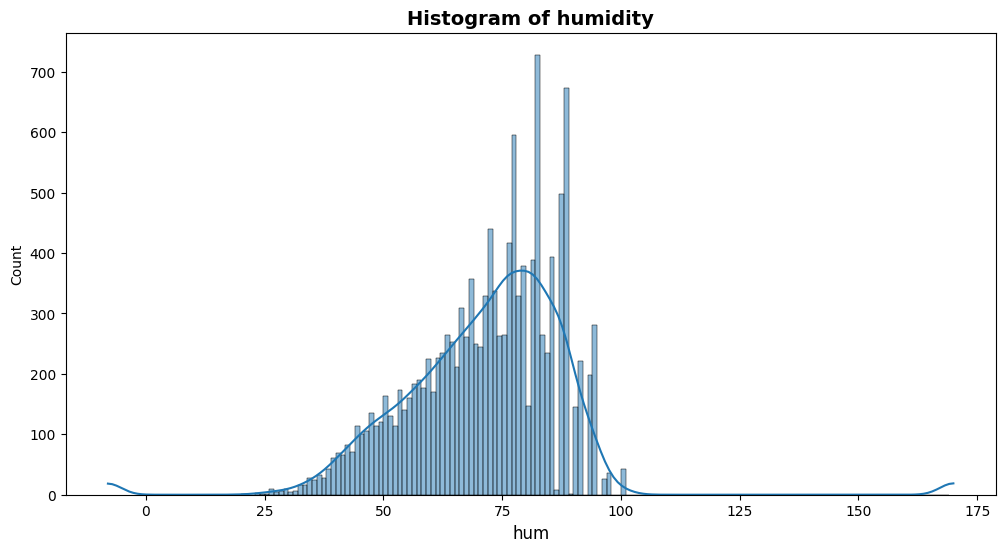

In [ ]:
# Create a professional histogram of house prices with clearly labeled x-axis
plt.figure(figsize=(12, 6))

# Define bin edges
bin_edges = range(0, int(df['hum'].max()) )

# Plot the histogram with defined bins
sns.histplot(data=df, x="hum", bins=bin_edges, kde=True)

# Set title and labels
plt.title("Histogram of humidity", fontsize=14, fontweight='bold')
plt.xlabel("hum", fontsize=12)


# Show the plot
plt.show()

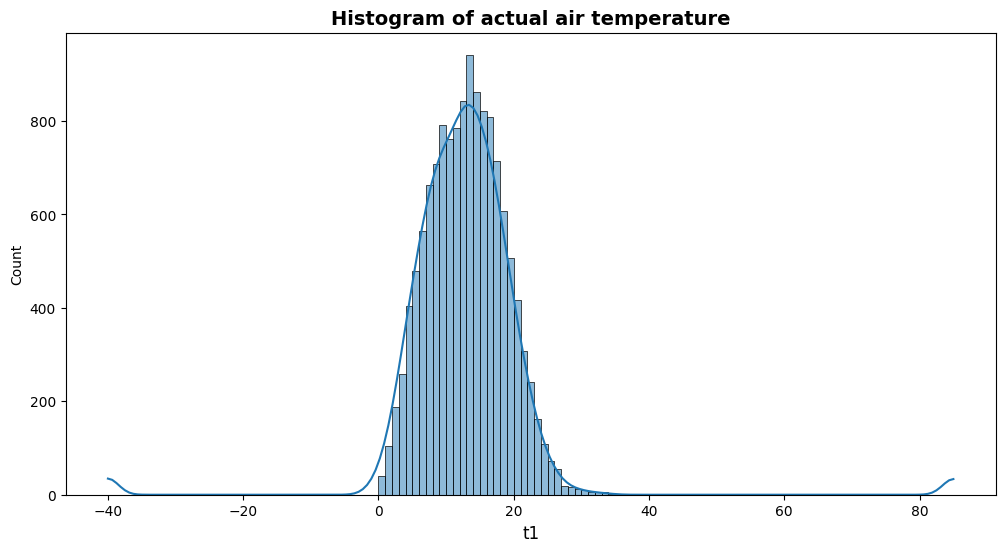

In [ ]:
# Create a professional histogram of house prices with clearly labeled x-axis
plt.figure(figsize=(12, 6))

# Define bin edges
bin_edges = range(0, int(df['t1'].max()) )

# Plot the histogram with defined bins
sns.histplot(data=df, x="t1", bins=bin_edges, kde=True)

# Set title and labels
plt.title("Histogram of actual air temperature", fontsize=14, fontweight='bold')
plt.xlabel("t1", fontsize=12)


# Show the plot
plt.show()

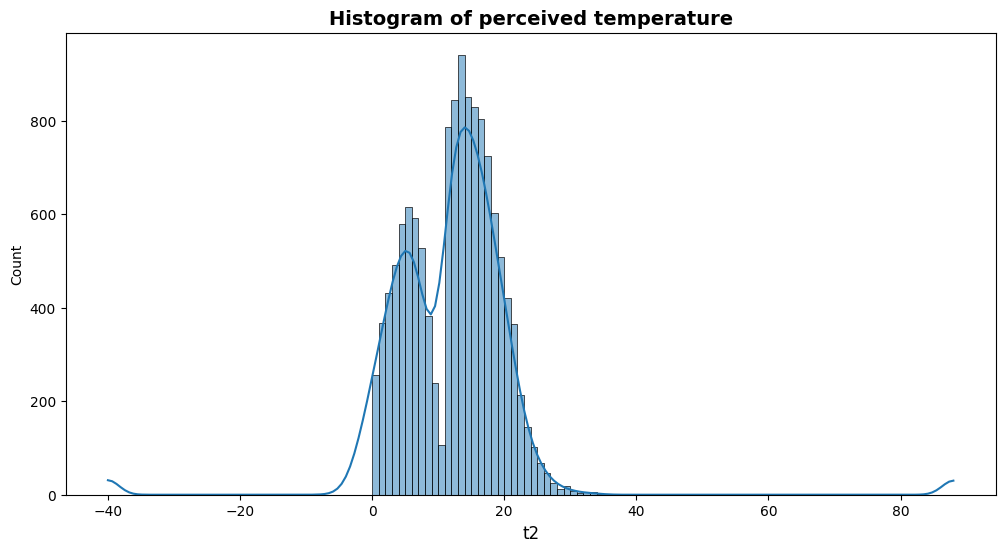

In [ ]:
# Create a professional histogram of house prices with clearly labeled x-axis
plt.figure(figsize=(12, 6))

# Define bin edges
bin_edges = range(0, int(df['t2'].max()) )

# Plot the histogram with defined bins
sns.histplot(data=df, x="t2", bins=bin_edges, kde=True)

# Set title and labels
plt.title("Histogram of perceived temperature", fontsize=14, fontweight='bold')
plt.xlabel("t2", fontsize=12)


# Show the plot
plt.show()

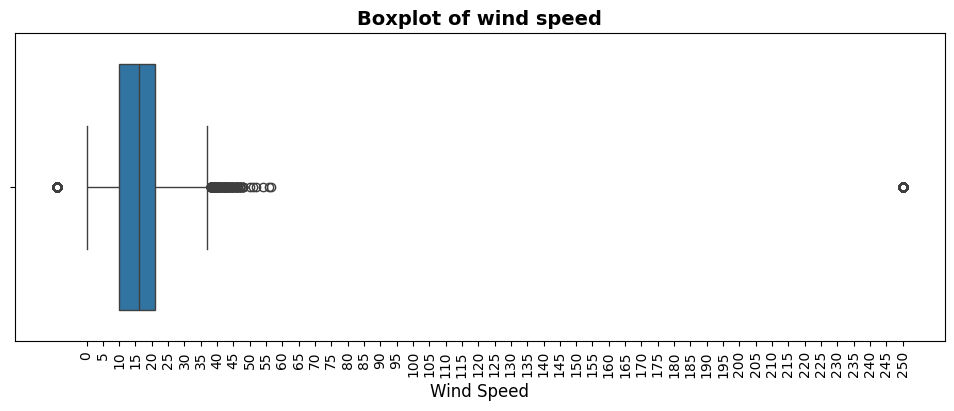

In [ ]:
# Create a professional horizontal boxplot for 'wind_speed' with k-format x-axis
plt.figure(figsize=(12, 4))

# Plot the boxplot
sns.boxplot(data=df, x='wind_speed')

# Set title and labels
plt.title("Boxplot of wind speed", fontsize=14, fontweight='bold')
plt.xlabel("Wind Speed", fontsize=12)

# Adjusting the x-axis label and ticks
max_wind_speed = df['wind_speed'].max()
plt.xticks(ticks=range(0, int(max_wind_speed) + 5, 5),
           rotation=90)

# Show the plot
plt.show()


hour Summary:
 count    13545.000000
mean        11.511185
std          6.917829
min          0.000000
25%          6.000000
50%         12.000000
75%         17.000000
max         23.000000
Name: hour, dtype: float64
Missing: 0, Skewness: -0.00, Kurtosis: -1.20


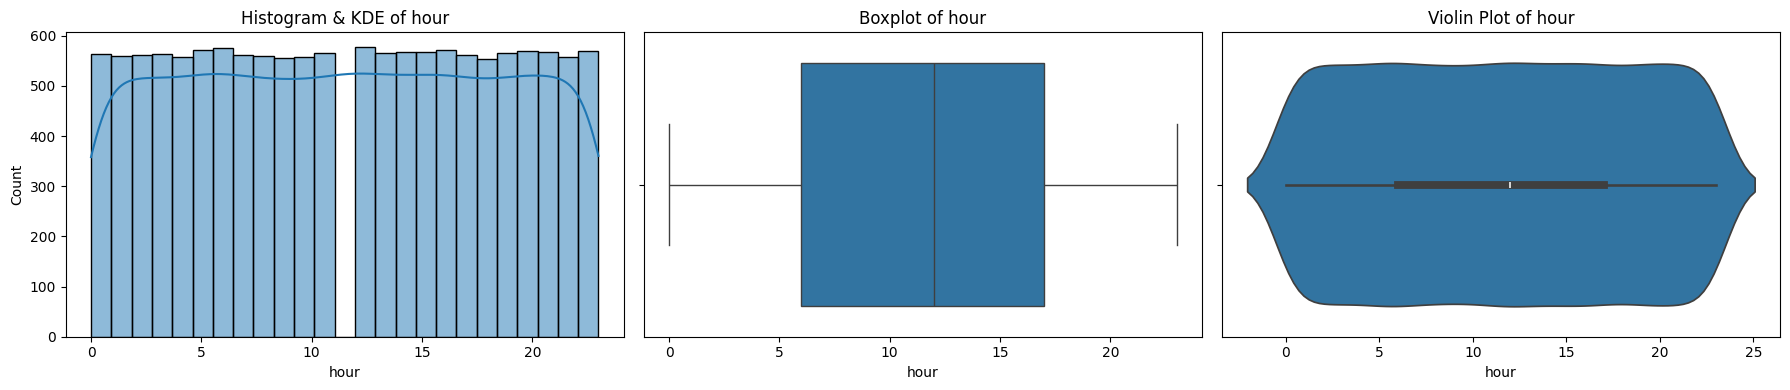


day Summary:
 count    13545.000000
mean        15.782429
std          8.776099
min          1.000000
25%          8.000000
50%         16.000000
75%         23.000000
max         31.000000
Name: day, dtype: float64
Missing: 0, Skewness: 0.01, Kurtosis: -1.19


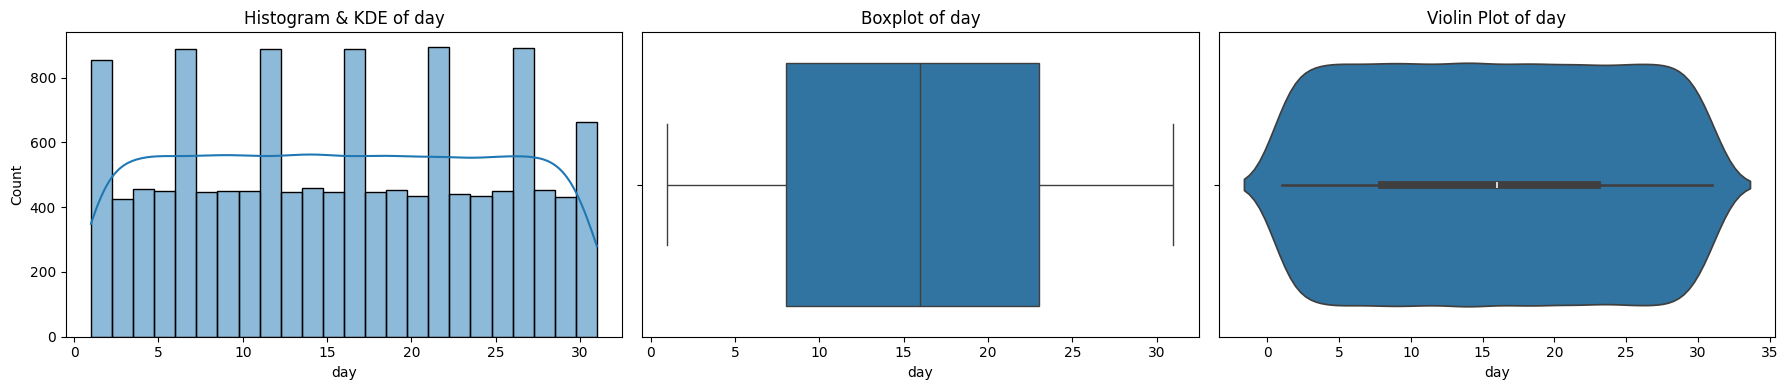


month Summary:
 count    13545.000000
mean         5.733260
std          3.180707
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         12.000000
Name: month, dtype: float64
Missing: 0, Skewness: 0.27, Kurtosis: -0.90


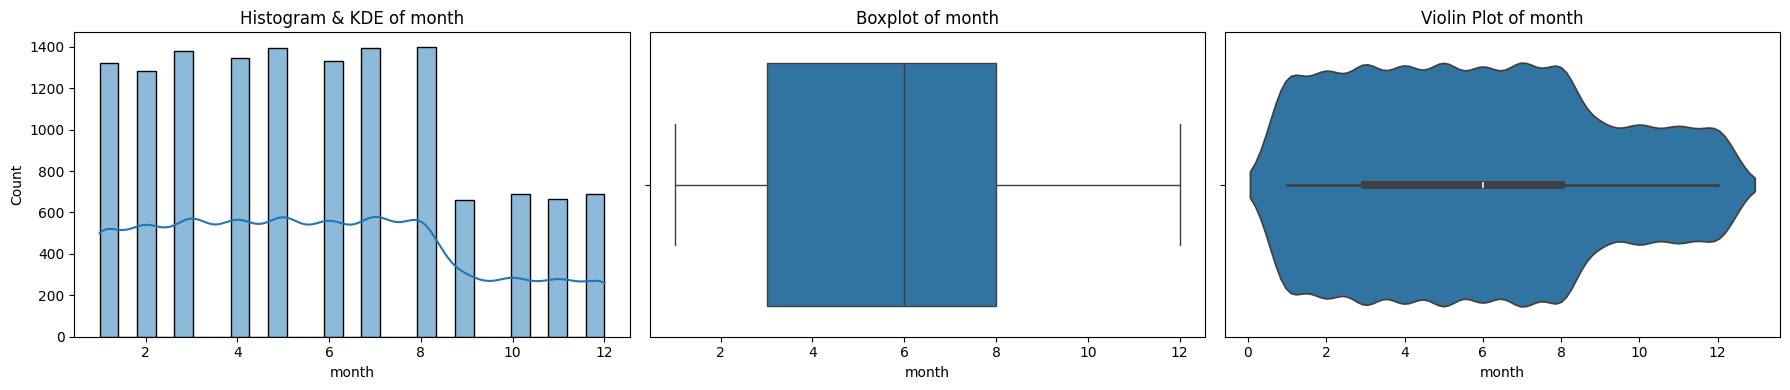


year Summary:
 count    13545.000000
mean      2015.403322
std          0.490582
min       2015.000000
25%       2015.000000
50%       2015.000000
75%       2016.000000
max       2016.000000
Name: year, dtype: float64
Missing: 0, Skewness: 0.39, Kurtosis: -1.84


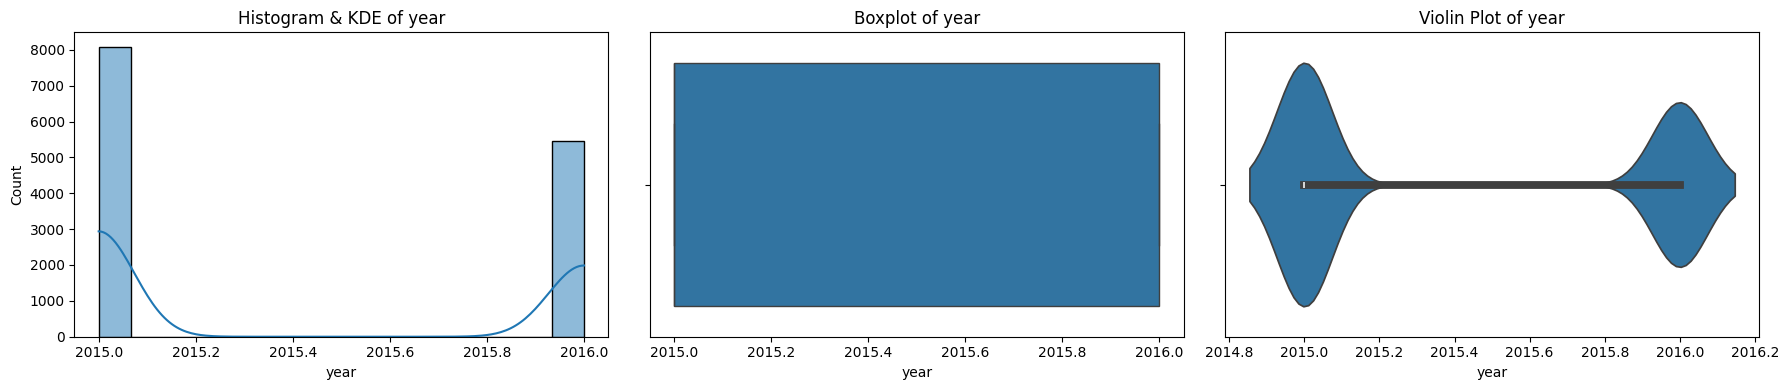


is_holiday Summary:
 count    13545.000000
mean         0.021779
std          0.145967
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: is_holiday, dtype: float64
Missing: 0, Skewness: 6.55, Kurtosis: 40.95


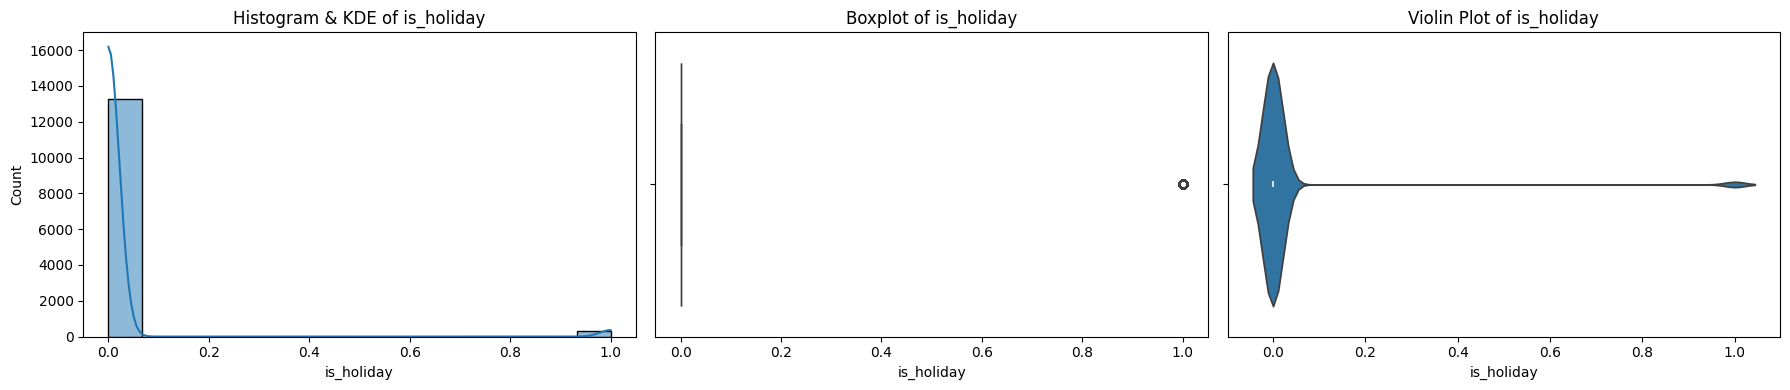


is_weekend Summary:
 count    13545.000000
mean         0.282318
std          0.450144
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: is_weekend, dtype: float64
Missing: 0, Skewness: 0.97, Kurtosis: -1.06


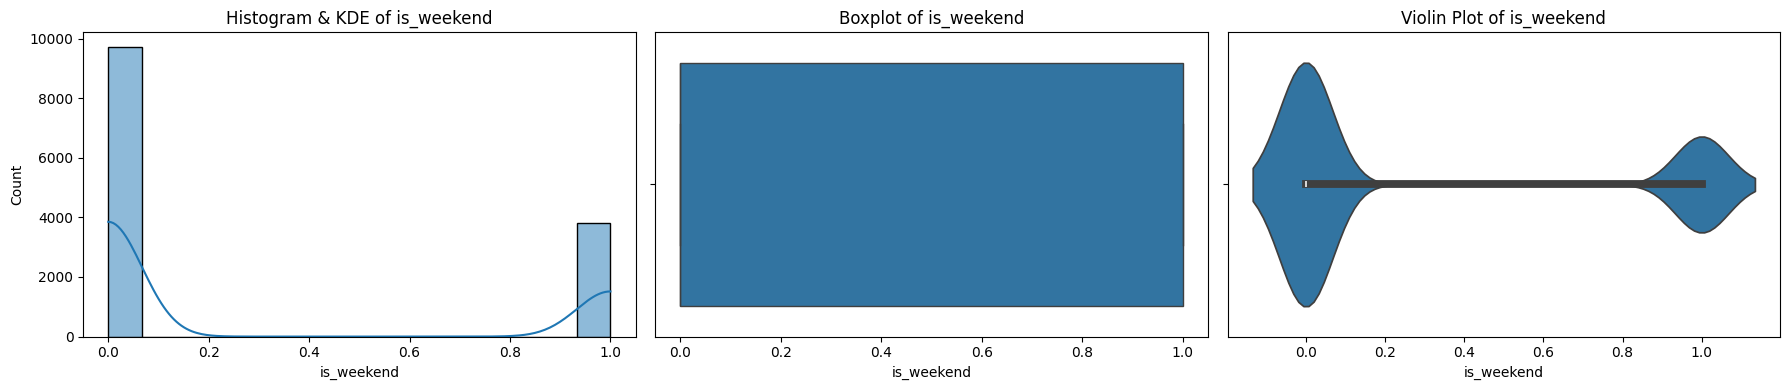


t1 Summary:
 count    13545.000000
mean        12.826504
std         10.551797
min        -40.000000
25%          8.500000
50%         13.000000
75%         17.000000
max         85.000000
Name: t1, dtype: float64
Missing: 0, Skewness: 1.91, Kurtosis: 25.48


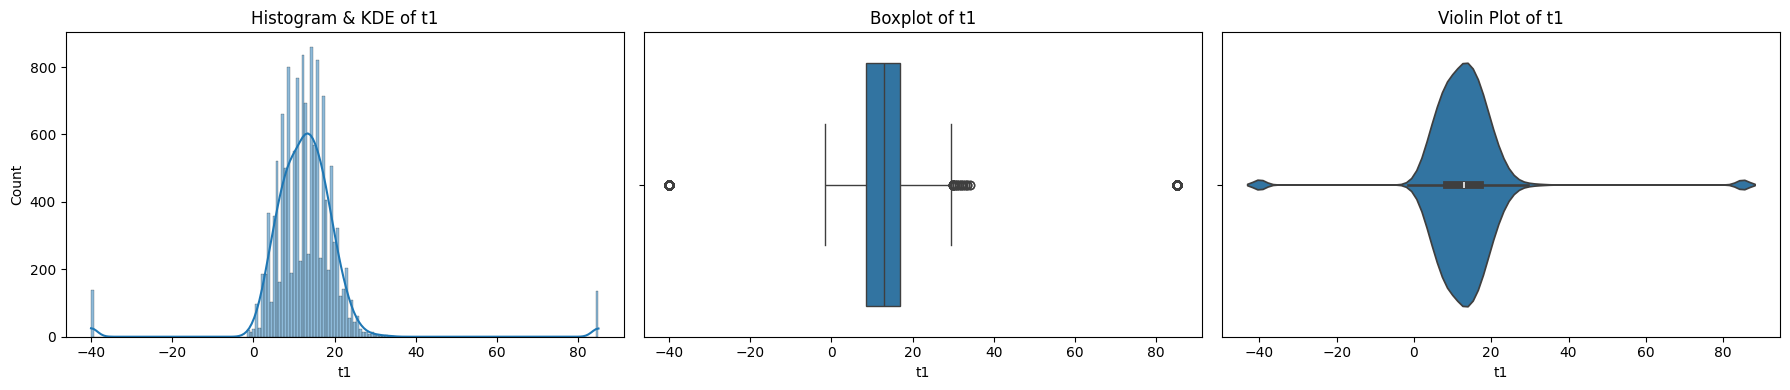


t2 Summary:
 count    13545.000000
mean        11.915836
std         11.305436
min        -40.000000
25%          6.000000
50%         13.000000
75%         17.000000
max         88.000000
Name: t2, dtype: float64
Missing: 0, Skewness: 1.97, Kurtosis: 21.93


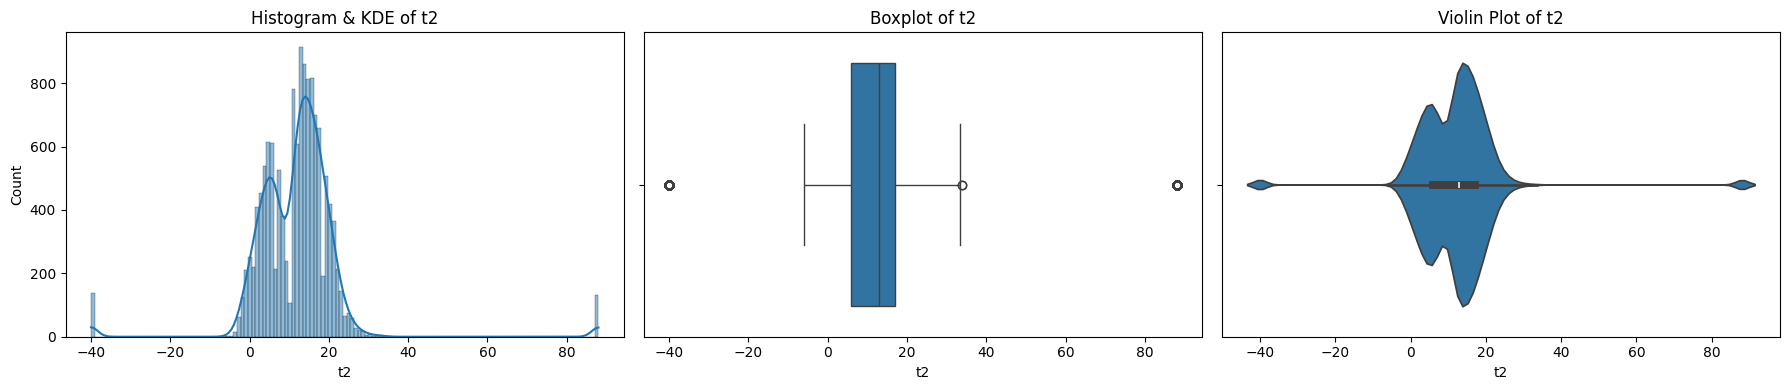


hum Summary:
 count    13545.000000
mean        71.375581
std         19.007652
min         -8.000000
25%         61.000000
50%         73.500000
75%         82.000000
max        170.000000
Name: hum, dtype: float64
Missing: 0, Skewness: 0.43, Kurtosis: 8.07


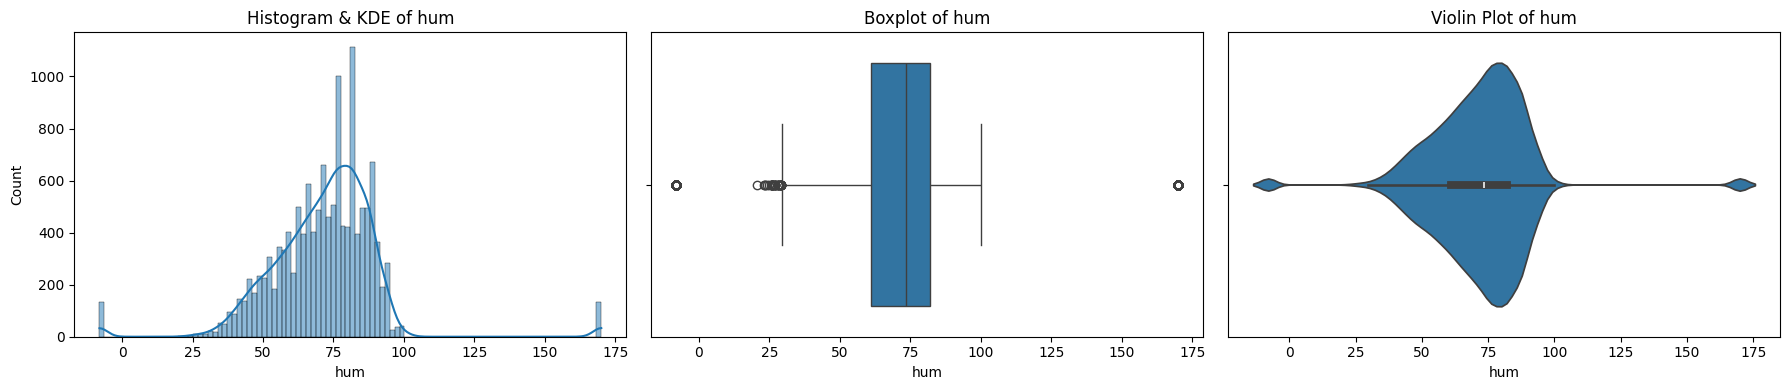


wind_speed Summary:
 count    13545.000000
mean        18.524948
std         24.734434
min         -9.000000
25%         10.000000
50%         16.000000
75%         21.000000
max        250.000000
Name: wind_speed, dtype: float64
Missing: 0, Skewness: 8.21, Kurtosis: 74.10


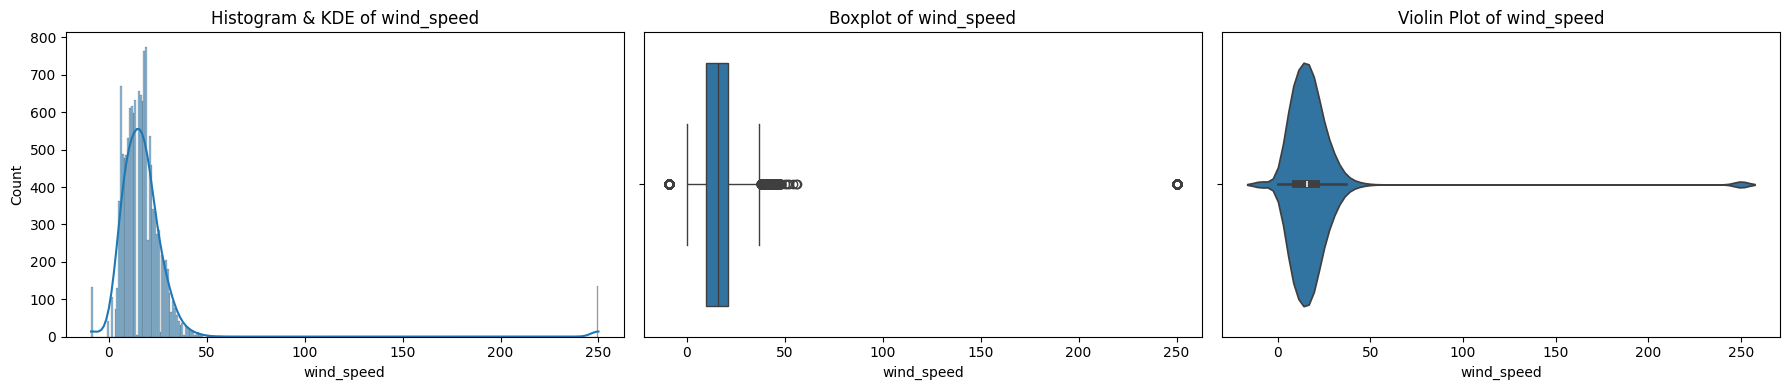


weather_code Summary:
 count    13545.000000
mean         2.731414
std          2.371302
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         26.000000
Name: weather_code, dtype: float64
Missing: 0, Skewness: 3.99, Kurtosis: 31.41


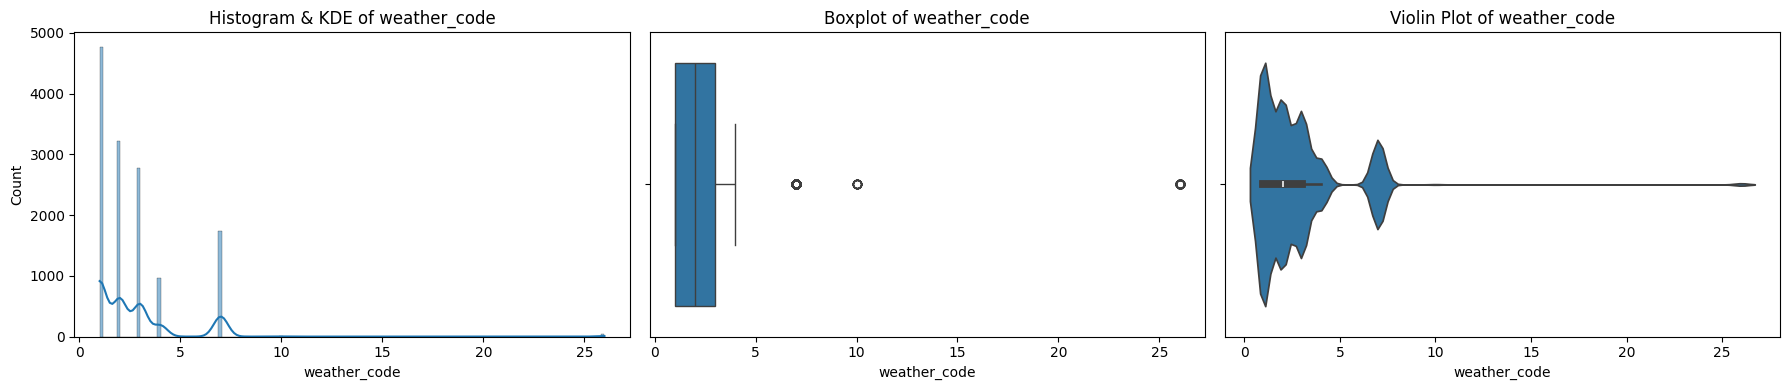


cnt Summary:
 count    13545.000000
mean      1322.538427
std       2163.375244
min        -13.000000
25%        242.000000
50%        844.000000
75%       1717.000000
max      20000.000000
Name: cnt, dtype: float64
Missing: 0, Skewness: 6.51, Kurtosis: 52.64


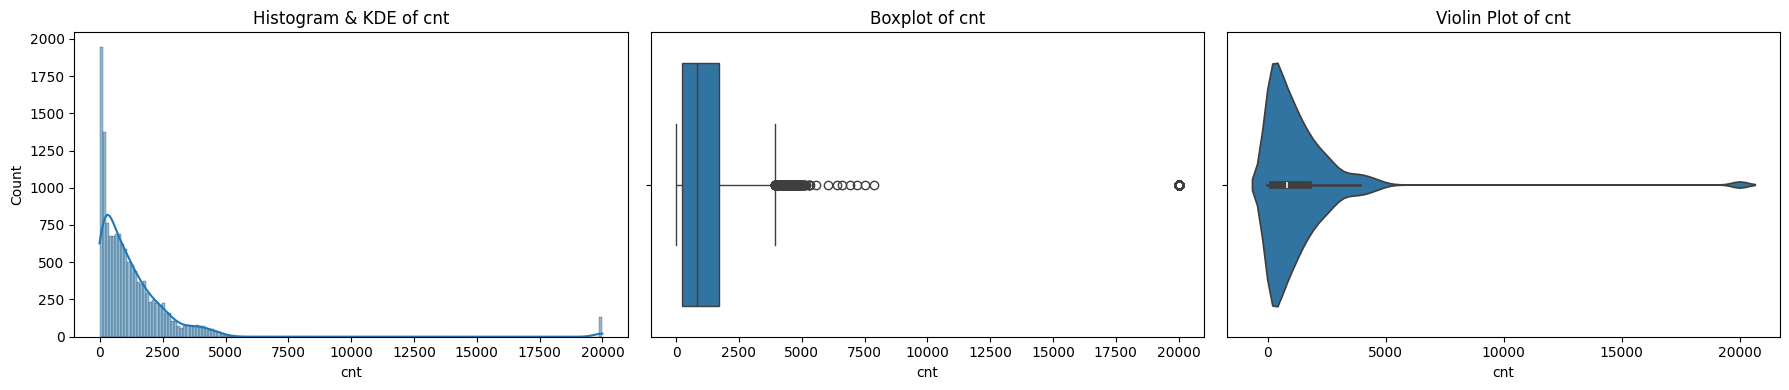

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    print(f"\n{col} Summary:\n", df[col].describe())
    print(f"Missing: {df[col].isna().sum()}, Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurtosis():.2f}")

    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    sns.histplot(df[col].dropna(), kde=True, ax=axs[0])
    axs[0].set_title(f'Histogram & KDE of {col}')

    sns.boxplot(x=df[col], ax=axs[1])
    axs[1].set_title(f'Boxplot of {col}')

    sns.violinplot(x=df[col], ax=axs[2])
    axs[2].set_title(f'Violin Plot of {col}')

    plt.tight_layout()
    plt.show()

OUTLIERS

In [ ]:
# IQR methods
# Compute IQR for 'cnt'
Q1 = df['cnt'].quantile(0.25)
Q3 = df['cnt'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['cnt'] < lower_bound) | (df['cnt'] > upper_bound)]

# Display the number of outliers detected
num_outliers = outliers.shape[0]

# Show the summary and a few outliers
print(f'Any cnt < {lower_bound:.2f} or cnt > {upper_bound:.2f} are identified as outliers')
print(f'Number of outliers in cnt column: {num_outliers}')
print('Some sample outliers')
outliers

Any cnt < -1970.50 or cnt > 3929.50 are identified as outliers
Number of outliers in cnt column: 549
Some sample outliers


,timestamp,hour,day,month,year,is_holiday,is_weekend,season,t1,t2,hum,wind_speed,weather_code,cnt
223,2015-01-13 08:00:00,8,13,1,2015,0.0,0.0,Winter,9.0,6.5,-8.0,16.0,2.0,3960.0
259,2015-01-14 20:00:00,20,14,1,2015,0.0,0.0,Winter,10.0,6.0,69.0,31.0,3.0,20000.0
278,2015-01-15 15:00:00,15,15,1,2015,0.0,0.0,Winter,9.0,5.0,52.0,36.0,2.0,20000.0
498,2015-01-24 19:00:00,19,24,1,2015,0.0,1.0,Winter,5.0,2.0,68.0,14.0,1.0,20000.0
522,2015-01-25 19:00:00,19,25,1,2015,0.0,1.0,Winter,8.0,5.0,76.0,19.5,3.0,20000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14422,2016-08-30 17:00:00,17,30,8,2016,0.0,0.0,Summer,25.5,25.5,39.5,12.0,1.0,4889.0
14423,2016-08-30 18:00:00,18,30,8,2016,0.0,0.0,Summer,24.5,24.5,43.0,13.0,1.0,4703.0
14437,2016-08-31 08:00:00,8,31,8,2016,0.0,0.0,Summer,18.0,18.0,64.0,12.0,1.0,4807.0
14446,2016-08-31 17:00:00,17,31,8,2016,0.0,0.0,Summer,23.0,23.0,57.0,17.5,2.0,4522.0


In [ ]:
# Function to detect outliers using IQR
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)   # First quartile
    Q3 = data[col].quantile(0.75)   # Third quartile
    IQR = Q3 - Q1                   # Interquartile range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Flag rows outside bounds
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Apply to continuous numerical variables
num_vars = ['cnt','t2','t1','hum','wind_speed']

for var in num_vars:
    outliers, lb, ub = detect_outliers_iqr(df, var)
    print(f"{var}: {outliers.shape[0]} outliers detected")
    print(f"Lower bound: {lb:.3f}, Upper bound: {ub:.3f}\n")

cnt: 549 outliers detected
Lower bound: -1970.500, Upper bound: 3929.500

t2: 272 outliers detected
Lower bound: -10.500, Upper bound: 33.500

t1: 302 outliers detected
Lower bound: -4.250, Upper bound: 29.750

hum: 303 outliers detected
Lower bound: 29.500, Upper bound: 113.500

wind_speed: 443 outliers detected
Lower bound: -6.500, Upper bound: 37.500



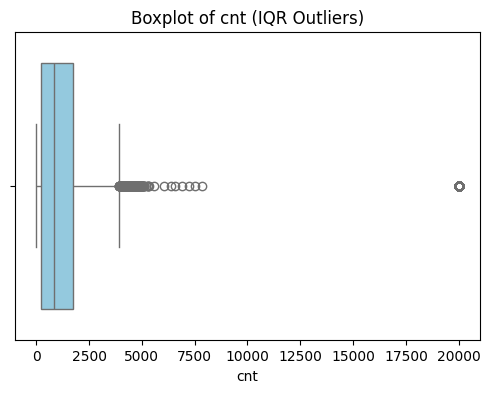

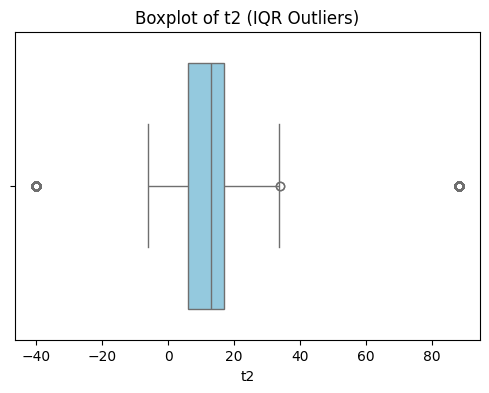

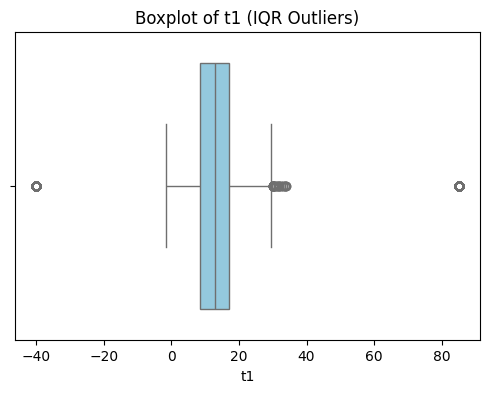

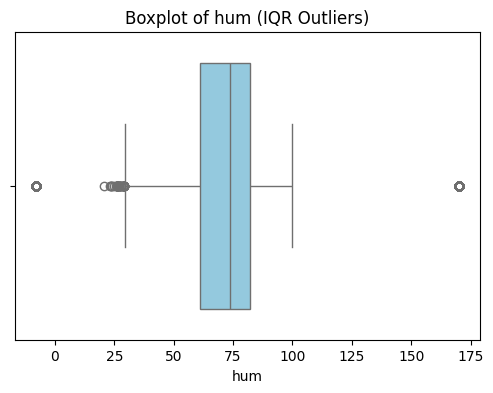

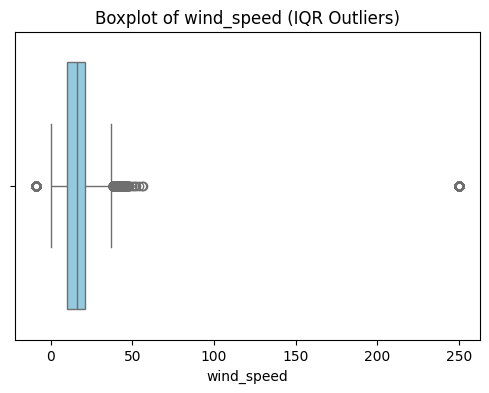

In [ ]:
# Continuous numerical variables
num_vars = ['cnt','t2','t1','hum','wind_speed']

# Loop through each variable
for var in num_vars:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[var], color="skyblue")
    plt.title(f'Boxplot of {var} (IQR Outliers)')
    plt.show()

Handling outliers

In [ ]:
# Function to apply Winsorization (capping outliers)
def apply_winsorization(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values at the lower and upper bounds
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    print(f"Outliers in '{col}' capped at lower bound: {lower_bound:.2f} and upper bound: {upper_bound:.2f}")
    return df

# Continuous numerical variables to winsorize
num_vars_to_winsorize = ['cnt', 't2', 't1', 'hum', 'wind_speed']

# Apply winsorization to each variable
for var in num_vars_to_winsorize:
    df = apply_winsorization(df.copy(), var)

print("\nDescriptive statistics after winsorization:")
display(df[num_vars_to_winsorize].describe())

Outliers in 'cnt' capped at lower bound: -1970.50 and upper bound: 3929.50
Outliers in 't2' capped at lower bound: -10.50 and upper bound: 33.50
Outliers in 't1' capped at lower bound: -4.25 and upper bound: 29.75
Outliers in 'hum' capped at lower bound: 29.50 and upper bound: 113.50
Outliers in 'wind_speed' capped at lower bound: -6.50 and upper bound: 37.50

Descriptive statistics after winsorization:


,cnt,t2,t1,hum,wind_speed
count,13545.000000,13545.000000,13545.000000,13545.000000,13545.000000
mean,1147.622185,11.678996,12.639018,71.187837,16.362785
std,1072.260090,7.300880,6.037916,15.385399,8.308661
min,-13.000000,-10.500000,-4.250000,29.500000,-6.500000
25%,242.000000,6.000000,8.500000,61.000000,10.000000
50%,844.000000,13.000000,13.000000,73.500000,16.000000
75%,1717.000000,17.000000,17.000000,82.000000,21.000000
max,3929.500000,33.500000,29.750000,113.500000,37.500000


### CATEGORICAL DATA

In [ ]:
df.head()

,timestamp,hour,day,month,year,is_holiday,is_weekend,season,t1,t2,hum,wind_speed,weather_code,cnt
0,2015-01-04 00:00:00,0,4,1,2015,0.0,1.0,Winter,3.0,2.0,93.0,6.0,3.0,182.0
1,2015-01-04 01:00:00,1,4,1,2015,0.0,1.0,Winter,3.0,2.5,93.0,5.0,1.0,138.0
2,2015-01-04 02:00:00,2,4,1,2015,0.0,1.0,Winter,2.5,2.5,96.5,0.0,1.0,134.0
3,2015-01-04 03:00:00,3,4,1,2015,0.0,1.0,Winter,2.0,2.0,100.0,0.0,1.0,72.0
4,2015-01-04 04:00:00,4,4,1,2015,0.0,1.0,Winter,2.0,0.0,93.0,6.5,1.0,47.0


In [ ]:
# Define your categorical columns here
categorical_cols = ['hour', 'weather_code', 'season', 'is_holiday', 'is_weekend', 'year', 'day']
df[categorical_cols] = df[categorical_cols].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13545 entries, 0 to 14452
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   timestamp     13545 non-null  object  
 1   hour          13545 non-null  category
 2   day           13545 non-null  category
 3   month         13545 non-null  int64   
 4   year          13545 non-null  category
 5   is_holiday    13545 non-null  category
 6   is_weekend    13545 non-null  category
 7   season        13545 non-null  category
 8   t1            13545 non-null  float64 
 9   t2            13545 non-null  float64 
 10  hum           13545 non-null  float64 
 11  wind_speed    13545 non-null  float64 
 12  weather_code  13545 non-null  category
 13  cnt           13545 non-null  float64 
dtypes: category(7), float64(5), int64(1), object(1)
memory usage: 1.4+ MB


In [ ]:
df.describe(include='category')


,hour,day,year,is_holiday,is_weekend,season,weather_code
count,13545,13545,13545,13545.0,13545.0,13545,13545.0
unique,24,31,2,2.0,2.0,5,7.0
top,12,14,2015,0.0,0.0,Spring,1.0
freq,578,459,8082,13250.0,9721.0,4087,4769.0


In [ ]:
# Count occurrences of each property type
df[['hour','weather_code', 'season', 'is_holiday', 'is_weekend', 'year', 'day']].value_counts()

hour  weather_code  season  is_holiday  is_weekend  year  day
19    1.0           Spring  0.0         0.0         2015  20     3
13    1.0           Spring  0.0         0.0         2015  27     3
2     1.0           Summer  0.0         0.0         2015  24     3
21    1.0           Summer  0.0         0.0         2016  22     3
19    1.0           Spring  0.0         0.0         2015  27     3
                                                                ..
8     2.0           Summer  0.0         0.0         2015  21     1
                                                          23     1
                                                          27     1
                                                          28     1
                    Spring  1.0         0.0         2015  6      1
Name: count, Length: 12242, dtype: int64

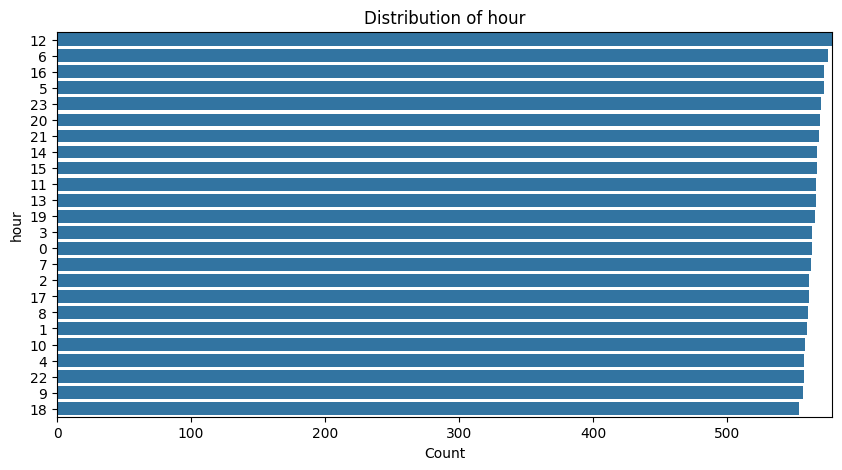

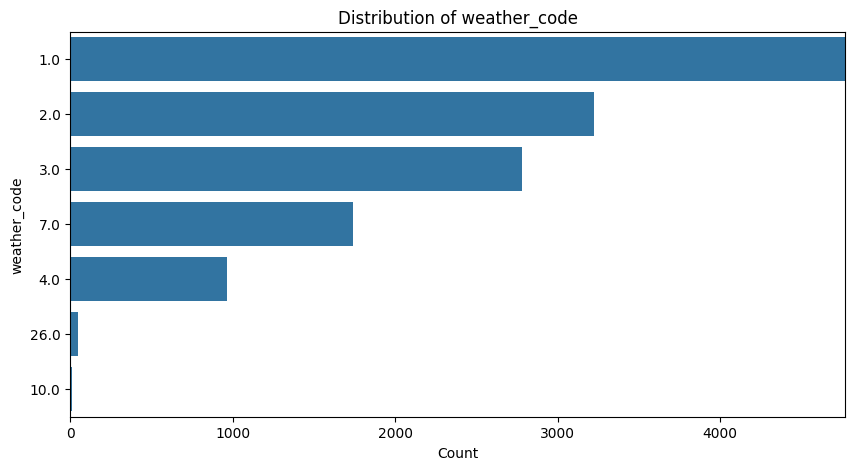

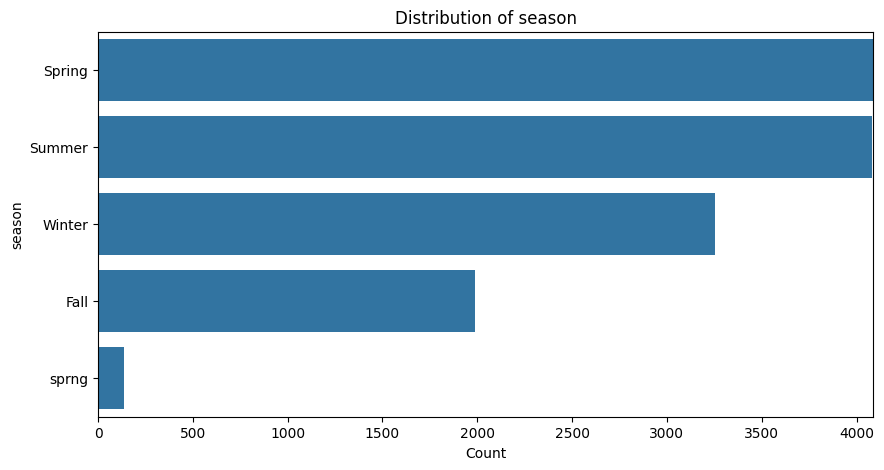

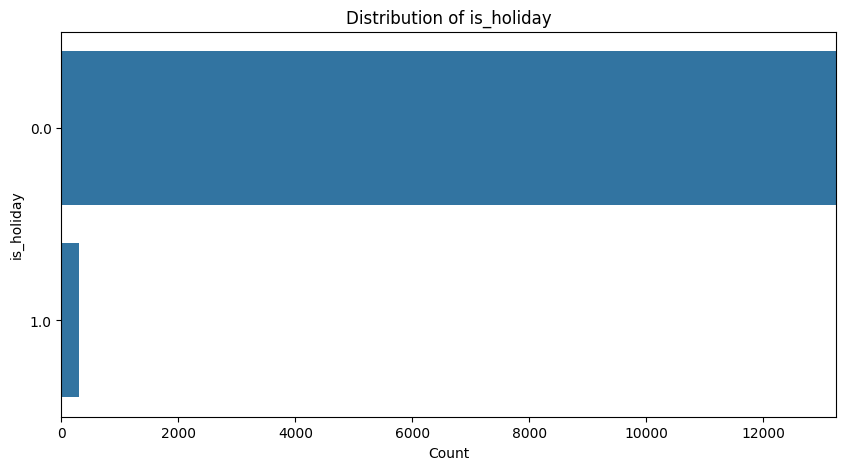

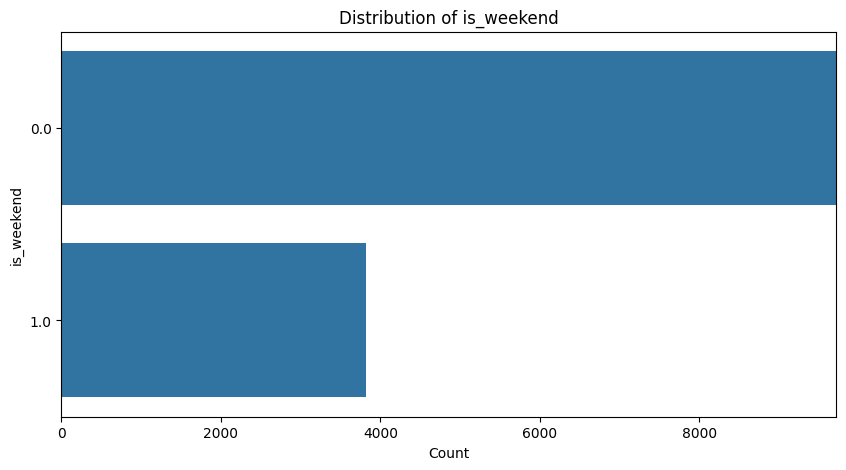

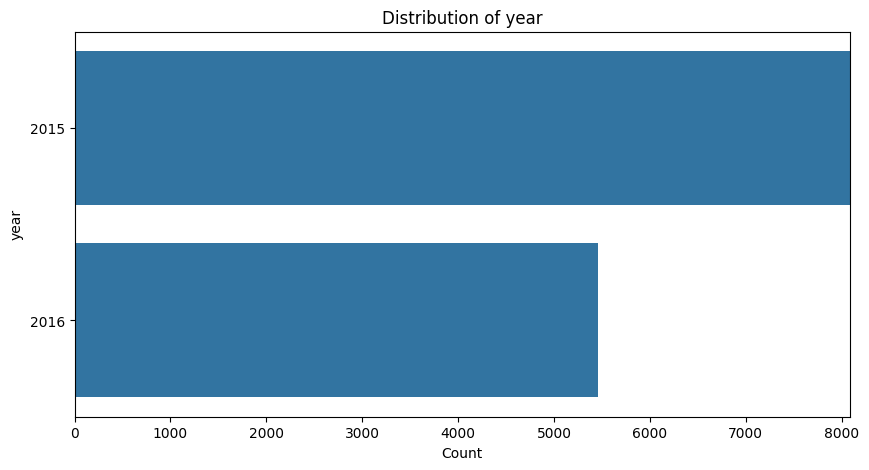

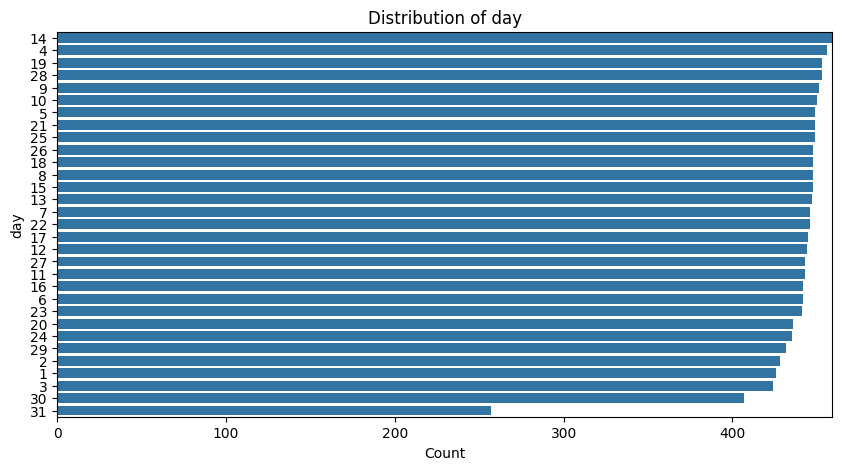

In [ ]:
# Visualizing categorical distributions
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    plt.margins(x=0)
    sns.countplot(data=df, y=col, order=df[col].value_counts().index,)
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
# Display summary statistics for categorical variables
print("Categorical Variable Summary:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("-" * 39)

Categorical Variable Summary:

Column: hour
hour
12    578
6     575
16    572
5     572
23    570
20    569
21    568
14    567
15    567
11    566
13    566
19    565
3     563
0     563
7     562
2     561
17    561
8     560
1     559
10    558
4     557
22    557
9     556
18    553
Name: count, dtype: int64
---------------------------------------

Column: weather_code
weather_code
1.0     4769
2.0     3226
3.0     2781
7.0     1743
4.0      966
26.0      48
10.0      12
Name: count, dtype: int64
---------------------------------------

Column: season
season
Spring    4087
Summer    4083
Winter    3253
Fall      1987
sprng      135
Name: count, dtype: int64
---------------------------------------

Column: is_holiday
is_holiday
0.0    13250
1.0      295
Name: count, dtype: int64
---------------------------------------

Column: is_weekend
is_weekend
0.0    9721
1.0    3824
Name: count, dtype: int64
---------------------------------------

Column: year
year
2015    8082
2016    5463
